Source:

https://dylancastillo.co/posts/react-agent-langgraph.html

**Vanilla ReAct agent**

In [1]:
from typing import Literal

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, MessagesState, StateGraph

load_dotenv()

model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

In [2]:
@tool
def run_python_code(code: str) -> str:
    """Run arbitrary Python code including imports, assignments, and statements. Do not use any external libraries. Save your results as a variable.

    Args:
        code: Python code to run
    """
    import sys
    from io import StringIO

    old_stdout = sys.stdout
    sys.stdout = captured_output = StringIO()

    namespace = {}

    try:
        exec(code, namespace)

        output = captured_output.getvalue()

        if not output.strip():
            user_vars = {
                k: v
                for k, v in namespace.items()
                if not k.startswith("__") and k not in ["StringIO", "sys"]
            }
            if user_vars:
                if len(user_vars) == 1:
                    output = str(list(user_vars.values())[0])
                else:
                    output = str(user_vars)

        return output.strip() if output.strip() else "Code executed successfully"

    except Exception as e:
        return f"Error: {str(e)}"
    finally:
        sys.stdout = old_stdout


tools = [run_python_code]
tools_mapping = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

In [3]:
def run_agent(question: str):
    messages = [
        SystemMessage(
            "You're a helpful assistant. Use the tools provided when relevant."
        ),
        HumanMessage(question),
    ]
    ai_message = model_with_tools.invoke(messages)
    messages.append(ai_message)

    while ai_message.tool_calls:
        for tool_call in ai_message.tool_calls:
            selected_tool = tools_mapping[tool_call["name"]]
            tool_msg = selected_tool.invoke(tool_call)
            messages.append(tool_msg)
        ai_message = model_with_tools.invoke(messages)
        messages.append(ai_message)

    return messages

In [4]:
messages = run_agent("Generate 10 random numbers between 1 and 100")

for m in messages:
    m.pretty_print()

================================ System Message ================================

You're a helpful assistant. Use the tools provided when relevant.
================================ Human Message =================================

Generate 10 random numbers between 1 and 100
================================== Ai Message ==================================
Tool Calls:
  run_python_code (call_A8cqI04UeUIKU8nHWFn1QMv6)
 Call ID: call_A8cqI04UeUIKU8nHWFn1QMv6
  Args:
    code: import random
random_numbers = [random.randint(1, 100) for _ in range(10)]
random_numbers
================================= Tool Message =================================
Name: run_python_code

{'random': <module 'random' from 'd:\\ProgramData\\Anaconda3\\envs\\waykilab-github\\Lib\\random.py'>, 'random_numbers': [32, 92, 16, 35, 4, 47, 84, 22, 5, 51]}
================================== Ai Message ==================================

Here are 10 random numbers between 1 and 100: 32, 92, 16, 35, 4, 47, 84, 22, 5, 51.


**LangGraph ReAct agent**

In [5]:
@tool
def run_python_code(code: str) -> str:
    """Run arbitrary Python code including imports, assignments, and statements. Do not use any external libraries. Save your results as a variable.

    Args:
        code: Python code to run
    """
    import sys
    from io import StringIO

    old_stdout = sys.stdout
    sys.stdout = captured_output = StringIO()

    namespace = {}

    try:
        exec(code, namespace)

        output = captured_output.getvalue()

        if not output.strip():
            user_vars = {
                k: v
                for k, v in namespace.items()
                if not k.startswith("__") and k not in ["StringIO", "sys"]
            }
            if user_vars:
                if len(user_vars) == 1:
                    output = str(list(user_vars.values())[0])
                else:
                    output = str(user_vars)

        return output.strip() if output.strip() else "Code executed successfully"

    except Exception as e:
        return f"Error: {str(e)}"
    finally:
        sys.stdout = old_stdout


tools = [run_python_code]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

In [6]:
def call_llm(state: MessagesState):
    messages = [
        SystemMessage(content="You are a helpful assistant that can run python code."),
    ] + state["messages"]
    return {"messages": [model_with_tools.invoke(messages)]}


def call_tool(state: MessagesState):
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


def should_continue(state: MessagesState) -> Literal["environment", END]:
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "Action"
    return END

In [7]:
agent_builder = StateGraph(MessagesState)

agent_builder.add_node("llm", call_llm)
agent_builder.add_node("environment", call_tool)

agent_builder.add_edge(START, "llm")
agent_builder.add_conditional_edges(
    "llm",
    should_continue,
    {
        "Action": "environment",
        END: END,
    },
)
agent_builder.add_edge("environment", "llm")

agent = agent_builder.compile()

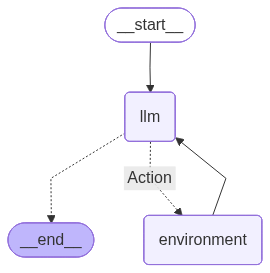

In [8]:
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [9]:
messages = [
    SystemMessage(content="You are a helpful assistant that can run python code."),
    HumanMessage(content="Generate 10 random numbers between 1 and 100"),
]

messages = agent.invoke({"messages": messages})

In [10]:
for m in messages["messages"]:
    m.pretty_print()

================================ System Message ================================

You are a helpful assistant that can run python code.
================================ Human Message =================================

Generate 10 random numbers between 1 and 100
================================== Ai Message ==================================
Tool Calls:
  run_python_code (call_5joWkYgVLQvmdQymyYbkOfEf)
 Call ID: call_5joWkYgVLQvmdQymyYbkOfEf
  Args:
    code: import random
random_numbers = [random.randint(1, 100) for _ in range(10)]
random_numbers
================================= Tool Message =================================

{'random': <module 'random' from 'd:\\ProgramData\\Anaconda3\\envs\\waykilab-github\\Lib\\random.py'>, 'random_numbers': [54, 65, 78, 81, 73, 100, 9, 39, 57, 48]}
================================== Ai Message ==================================

Here are 10 random numbers between 1 and 100: 54, 65, 78, 81, 73, 100, 9, 39, 57, 48.
